In [276]:
#!/usr/bin/env python3
"""Simple H5AD clustering tool with K-means, Bisecting K-means, and Leiden."""

import numpy as np
import warnings
warnings.filterwarnings('ignore')

import anndata as ad
import scanpy as sc
import pandas as pd
from sklearn.cluster import KMeans, BisectingKMeans
import matplotlib.pyplot as plt



In [277]:


def load_h5ad(filepath):
    """Load h5ad file and preprocess if needed."""
    print(f"Loading {filepath}...")
    adata = sc.read_h5ad(filepath)
    print(f"  {adata.n_obs} cells × {adata.n_vars} genes")
    
    # Preprocess if PCA not present
    if 'X_pca' not in adata.obsm:
        print("  Preprocessing...")
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
        sc.pp.highly_variable_genes(adata, n_top_genes=200)
        sc.pp.scale(adata, max_value=10)
        sc.tl.pca(adata, n_comps=50)
    
    return adata


def cluster_kmeans(adata, n_clusters=10):
    """K-means clustering."""
    print(f"Running K-means (k={n_clusters})...")
    data = adata.obsm['X_pca']
    labels = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit_predict(data)
    adata.obs['cluster'] = pd.Categorical([f"C{i}" for i in labels])
    return adata


def cluster_bisecting_kmeans(adata, n_clusters=10):
    """Bisecting K-means clustering."""
    print(f"Running Bisecting K-means (k={n_clusters})...")
    data = adata.obsm['X_pca']
    labels = BisectingKMeans(n_clusters=n_clusters, random_state=42).fit_predict(data)
    adata.obs['cluster'] = pd.Categorical([f"C{i}" for i in labels])
    return adata


def cluster_leiden(adata, resolution=1.0):
    """Leiden clustering."""
    print(f"Running Leiden (resolution={resolution})...")
    if 'neighbors' not in adata.uns:
        sc.pp.neighbors(adata, n_neighbors=15)
    sc.tl.leiden(adata, resolution=resolution, random_state=42)
    adata.obs['cluster'] = adata.obs['leiden']
    return adata


def plot_clusters(adata, save_path=None, spatial_key='spatial'):
    """Plot clusters on spatial x-y coordinates."""
    print("Plotting...")
    
    # Try to find spatial coordinates
    if spatial_key in adata.obsm:
        coords = adata.obsm[spatial_key]
    elif 'X_spatial' in adata.obsm:
        coords = adata.obsm['X_spatial']
    elif 'spatial' in adata.obs.columns and 'x' in adata.obs.columns:
        coords = adata.obs[['x', 'y']].values
    elif 'x' in adata.obs.columns and 'y' in adata.obs.columns:
        coords = adata.obs[['x', 'y']].values
    elif 'X' in adata.obs.columns and 'Y' in adata.obs.columns:
        coords = adata.obs[['X', 'Y']].values
    else:
        raise ValueError("No spatial coordinates found. Expected 'spatial' in obsm or 'x','y' in obs.")
    
    x = coords[:, 0]
    y = coords[:, 1]
    clusters = adata.obs['cluster']
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    for cluster in clusters.cat.categories:
        mask = clusters == cluster
        ax.scatter(x[mask], y[mask], label=cluster, alpha=0.7, s=20)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Spatial Clusters')
    ax.set_aspect('equal')
    ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()
    return fig


def show_clusters(adata):
    """Print cluster counts."""
    counts = adata.obs['cluster'].value_counts().sort_index()
    print(f"\nCluster counts ({len(counts)} clusters):")
    for name, count in counts.items():
        print(f"  {name}: {count} cells ({100*count/len(adata):.1f}%)")


def subcluster(adata, cluster_name, method='leiden', n_clusters=2, resolution=0.5):
    """Subcluster a specific cluster.
    
    Parameters
    ----------
    adata : AnnData
        Annotated data with existing 'cluster' column
    cluster_name : str
        Name of cluster to subdivide (e.g., '0' or 'C0')
    method : str
        'kmeans', 'bisecting_kmeans', or 'leiden'
    n_clusters : int
        Number of subclusters (for kmeans methods)
    resolution : float
        Resolution for Leiden
    
    Returns
    -------
    adata : AnnData
        Updated with new subcluster labels
    """
    mask = adata.obs['cluster'] == cluster_name
    n_cells = mask.sum()
    
    if n_cells == 0:
        print(f"Cluster '{cluster_name}' not found")
        return adata
    
    if n_cells < 10:
        print(f"Cluster '{cluster_name}' has only {n_cells} cells, too few to subcluster")
        return adata
    
    print(f"Subclustering '{cluster_name}' ({n_cells} cells)...")
    
    # Get subset
    sub_adata = adata[mask].copy()
    
    # Cluster subset
    if method == 'kmeans':
        data = sub_adata.obsm['X_pca']
        labels = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit_predict(data)
    elif method == 'bisecting_kmeans':
        data = sub_adata.obsm['X_pca']
        labels = BisectingKMeans(n_clusters=n_clusters, random_state=42).fit_predict(data)
    elif method == 'leiden':
        sc.pp.neighbors(sub_adata, n_neighbors=15)
        sc.tl.leiden(sub_adata, resolution=resolution, random_state=42)
        labels = sub_adata.obs['leiden'].values
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Update labels in original data
    new_labels = adata.obs['cluster'].astype(str).copy()
    indices = adata.obs_names[mask]
    for i, idx in enumerate(indices):
        new_labels[idx] = f"{cluster_name}.{labels[i]}"
    
    adata.obs['cluster'] = pd.Categorical(new_labels)
    print(f"  Split into {len(np.unique(labels))} subclusters")
    
    return adata

def merge_clusters(adata, clusters, new_name):
    """Merge multiple clusters into one.
    
    Parameters
    ----------
    adata : AnnData
        Annotated data with existing 'cluster' column
    clusters : list
        List of cluster names to merge (e.g., ['0', '1'] or ['0.0', '0.1'])
    new_name : str
        Name for the merged cluster
    
    Returns
    -------
    adata : AnnData
        Updated with merged cluster
    """
    new_labels = adata.obs['cluster'].astype(str).copy()
    
    total_cells = 0
    for cluster in clusters:
        mask = new_labels == str(cluster)
        n_cells = mask.sum()
        if n_cells == 0:
            print(f"  Warning: Cluster '{cluster}' not found")
        else:
            total_cells += n_cells
            new_labels[mask] = new_name
    
    adata.obs['cluster'] = pd.Categorical(new_labels)
    print(f"Merged {clusters} -> '{new_name}' ({total_cells} cells)")
    
    return adata



In [278]:
"""
# Example usage
if __name__ == "__main__":
  
    
    # Load and cluster
    adata = load_h5ad("demo.h5ad")
    
    # Choose one:
    # adata = cluster_kmeans(adata, n_clusters=5)
    # adata = cluster_bisecting_kmeans(adata, n_clusters=5)
    adata = cluster_leiden(adata, resolution=0.5)

    # Subcluster cluster "0" with kmeans into 3 parts
    adata = subcluster(adata, '0', method='kmeans', n_clusters=3)
    adata = subcluster(adata, 'C1', method='bisecting_kmeans', n_clusters=2)

    # Or with leiden
    adata = subcluster(adata, '1', method='leiden', resolution=0.3) 
    # Merge clusters 0 and 1 into one
    adata = merge_clusters(adata, ['0', '1'], 'merged_01')

    # Or merge subclusters
    adata = merge_clusters(adata, ['0.0', '0.1', '0.2'], 'group_A')
    show_clusters(adata)
    plot_clusters(adata, save_path="clusters.png")
    
    # Save results
    adata.write_h5ad("demo_clustered.h5ad")
    print("Done!")
    """

'\n# Example usage\nif __name__ == "__main__":\n  \n    \n    # Load and cluster\n    adata = load_h5ad("demo.h5ad")\n    \n    # Choose one:\n    # adata = cluster_kmeans(adata, n_clusters=5)\n    # adata = cluster_bisecting_kmeans(adata, n_clusters=5)\n    adata = cluster_leiden(adata, resolution=0.5)\n\n    # Subcluster cluster "0" with kmeans into 3 parts\n    adata = subcluster(adata, \'0\', method=\'kmeans\', n_clusters=3)\n    adata = subcluster(adata, \'C1\', method=\'bisecting_kmeans\', n_clusters=2)\n\n    # Or with leiden\n    adata = subcluster(adata, \'1\', method=\'leiden\', resolution=0.3) \n    # Merge clusters 0 and 1 into one\n    adata = merge_clusters(adata, [\'0\', \'1\'], \'merged_01\')\n\n    # Or merge subclusters\n    adata = merge_clusters(adata, [\'0.0\', \'0.1\', \'0.2\'], \'group_A\')\n    show_clusters(adata)\n    plot_clusters(adata, save_path="clusters.png")\n    \n    # Save results\n    adata.write_h5ad("demo_clustered.h5ad")\n    print("Done!")\n    '

Loading /home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered_halfbrain_common/halfbrain_yc_2_filtered_common.h5ad...
  7858 cells × 528 genes
  Preprocessing...
Running Bisecting K-means (k=2)...
Plotting...


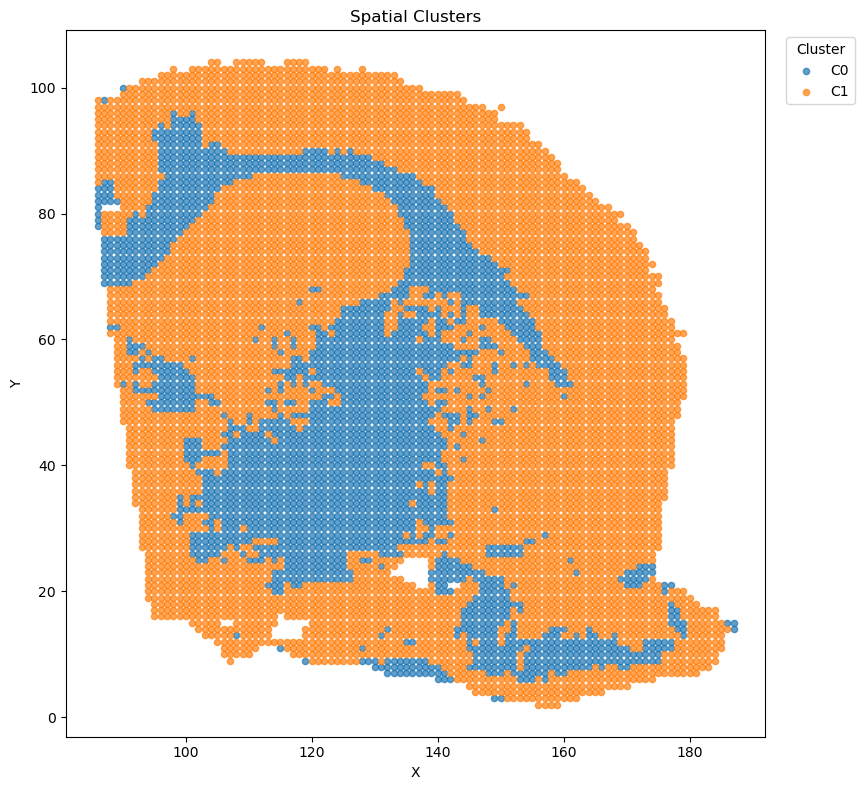

Done!


In [279]:
MSI_INPUT_FOLDER = "/home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered_halfbrain_common/"
MSI_SAMPLE_FILES = [
    "halfbrain_yc_1_filtered_common.h5ad", "halfbrain_yc_2_filtered_common.h5ad",
    "halfbrain_yc_3_filtered_common.h5ad", "halfbrain_yc_4_filtered_common.h5ad",
    "halfbrain_yad_1_filtered_common.h5ad", "halfbrain_yad_2_filtered_common.h5ad",
    "halfbrain_yad_3_filtered_common.h5ad", "halfbrain_yad_4_filtered_common.h5ad",
    "halfbrain_ac_1_filtered_common.h5ad", "halfbrain_ac_2_filtered_common.h5ad",
    "halfbrain_ac_3_filtered_common.h5ad", "halfbrain_ac_4_filtered_common.h5ad",
    "halfbrain_aad_1_filtered_common.h5ad", "halfbrain_aad_2_filtered_common.h5ad",
    "halfbrain_aad_3_filtered_common.h5ad", "halfbrain_aad_4_filtered_common.h5ad"
]

# Example usage
if __name__ == "__main__":
  
    
    # Load and cluster
    adata = load_h5ad(MSI_INPUT_FOLDER + MSI_SAMPLE_FILES[1])
    
    # Choose one:
    #adata = cluster_kmeans(adata, n_clusters=5)
    adata = cluster_bisecting_kmeans(adata, n_clusters=2)
    #adata = cluster_leiden(adata, resolution=0.3)
    
    #show_clusters(adata)
    plot_clusters(adata, save_path=None)
    
    # Save results
    #adata.write_h5ad("demo_clustered.h5ad")
    print("Done!")

Subclustering 'C1' (5467 cells)...
  Split into 2 subclusters
Plotting...


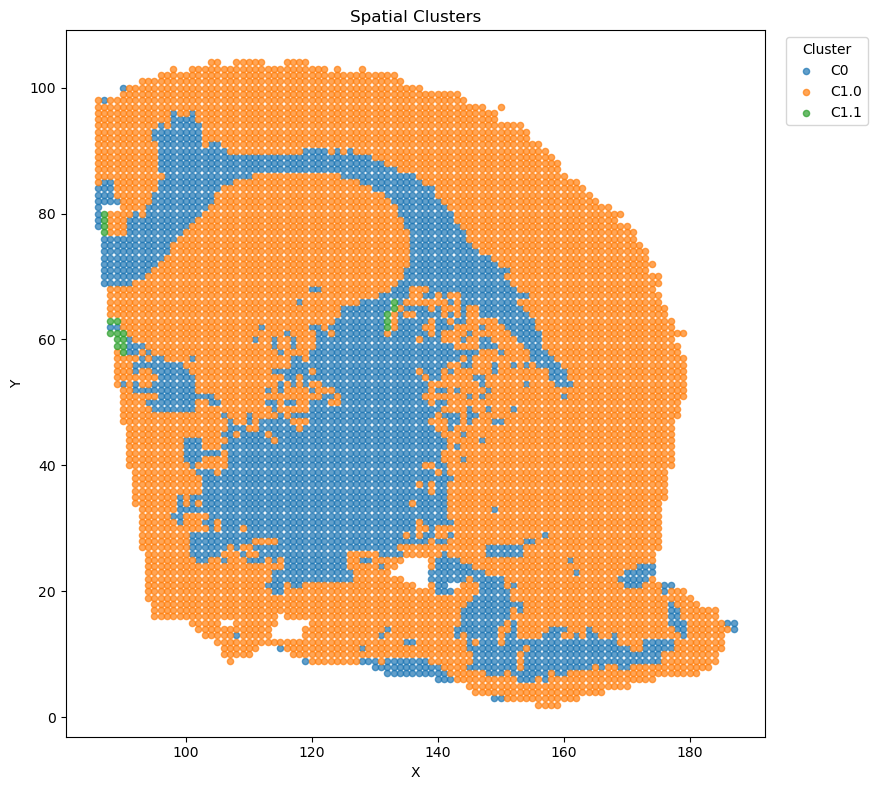

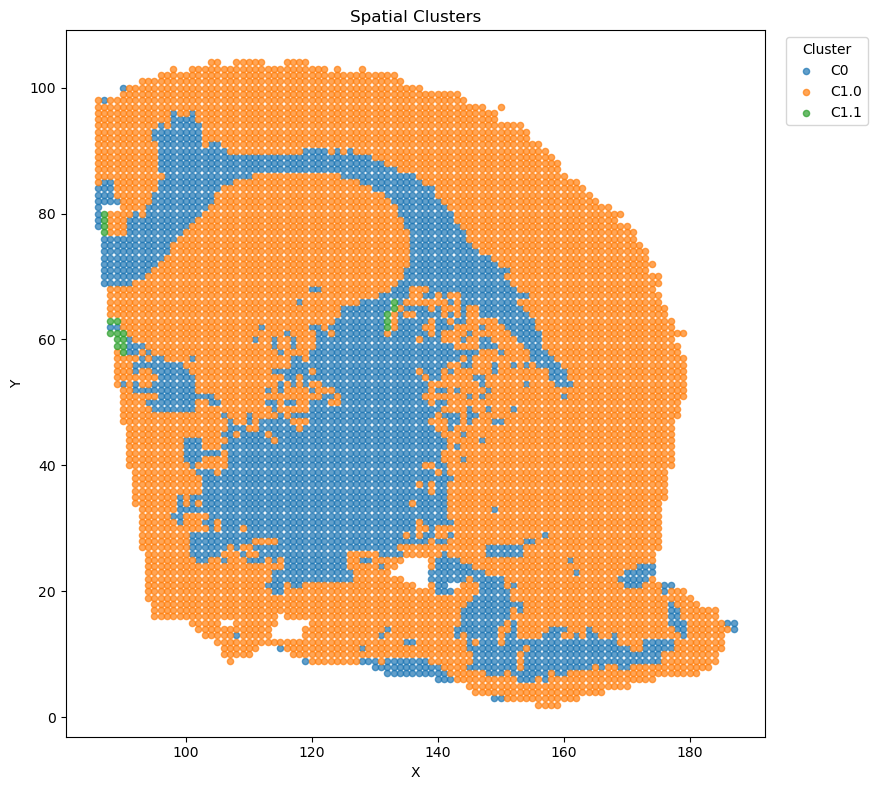

In [280]:
data = subcluster(adata, 'C1', method='leiden', resolution=0.05)
#adata = subcluster(adata, 'C1', method='kmeans', n_clusters=10)

plot_clusters(adata, save_path=None)


Subclustering 'C1.0' (5448 cells)...
  Split into 5 subclusters
Plotting...


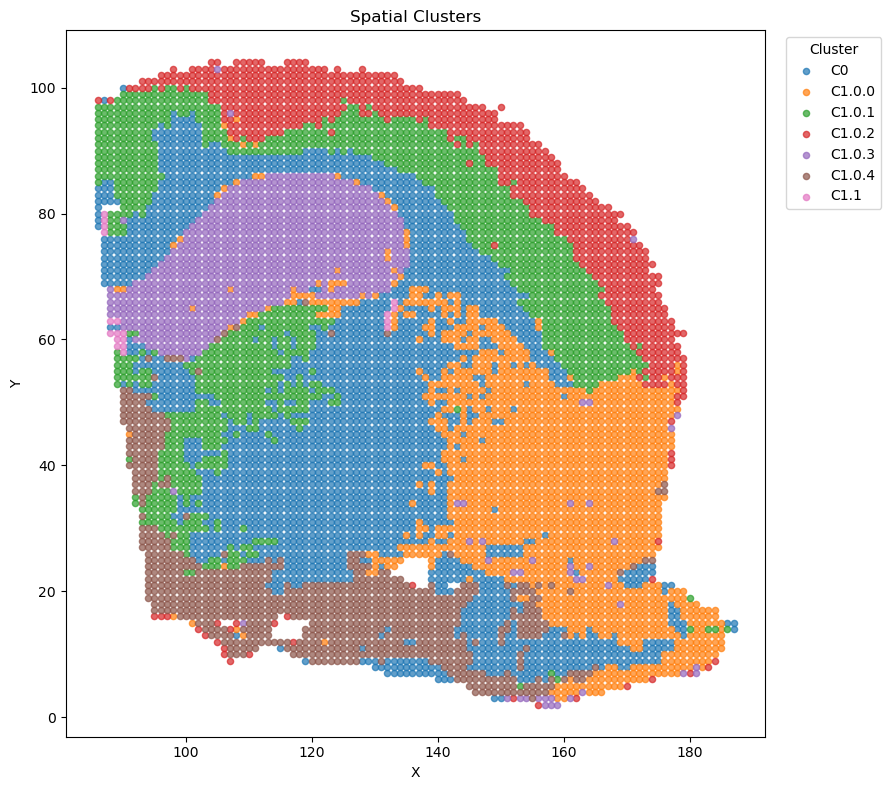

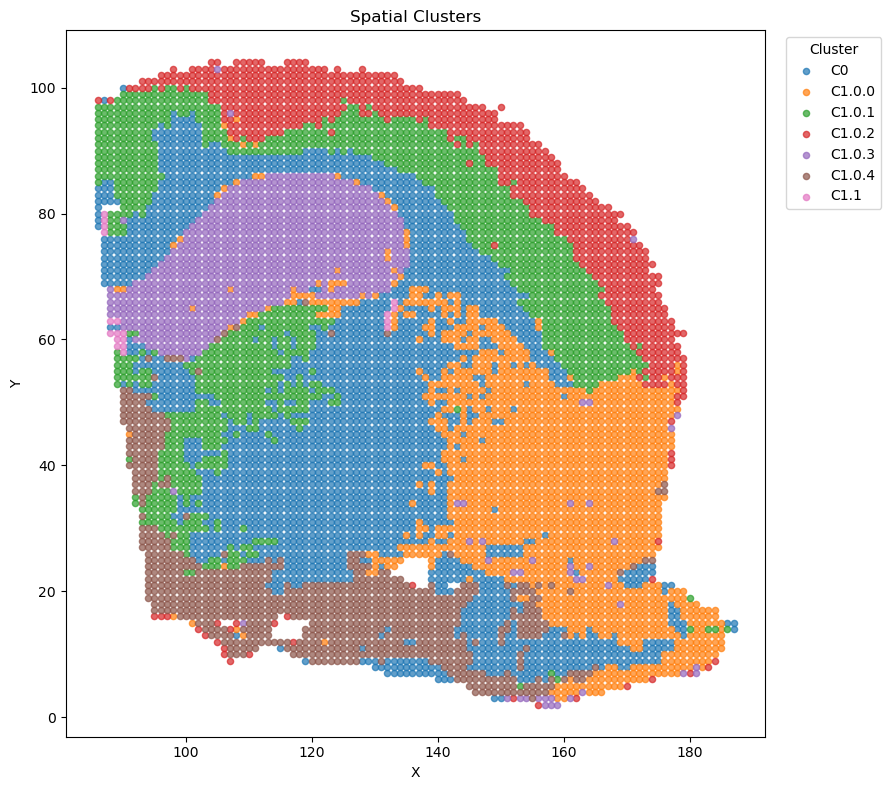

In [281]:
data = subcluster(adata, 'C1.0', method='leiden', resolution=0.2)
#adata = subcluster(adata, 'C1', method='kmeans', n_clusters=10)

plot_clusters(adata, save_path=None)

Subclustering 'C1.0.1' (1002 cells)...
  Split into 3 subclusters
Plotting...


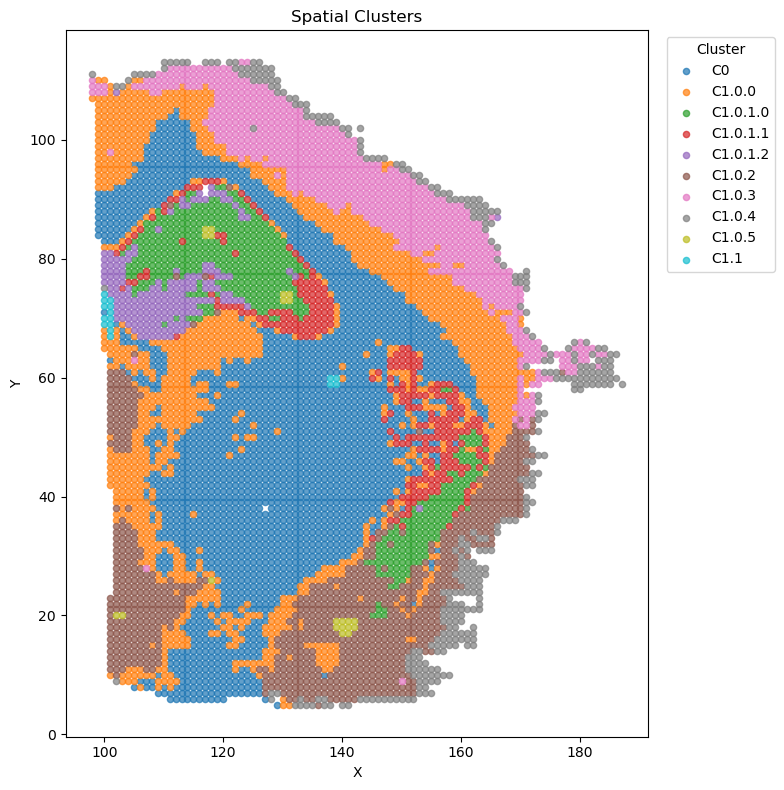

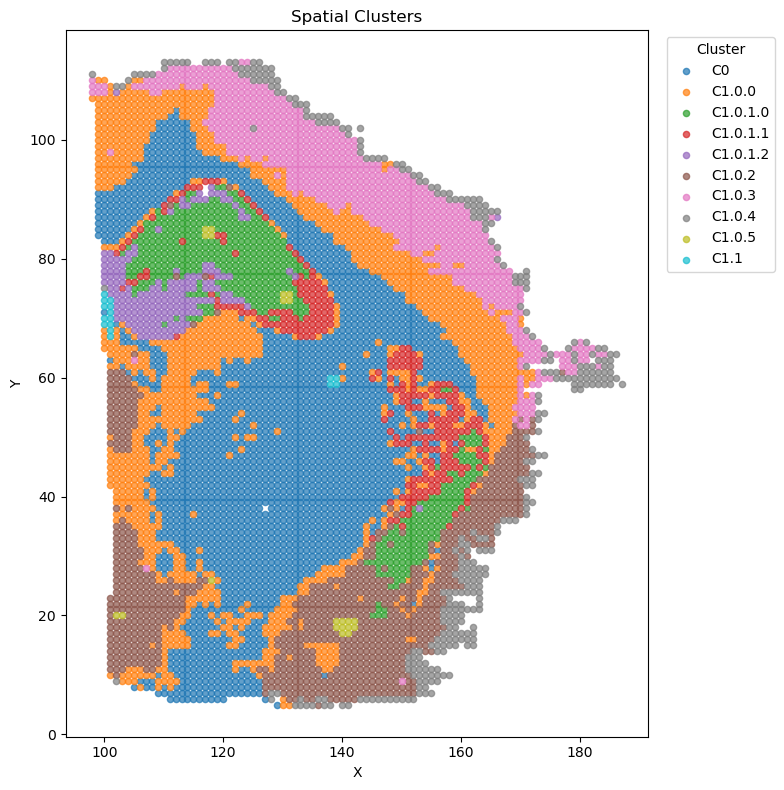

In [238]:
data = subcluster(adata, 'C1.0.1', method='leiden', resolution=0.4)
#adata = subcluster(adata, 'C1', method='kmeans', n_clusters=10)

plot_clusters(adata, save_path=None)

Merged ['C1.1.0', 'C1.1.1'] -> 'C1.1_merged' (1371 cells)
Plotting...


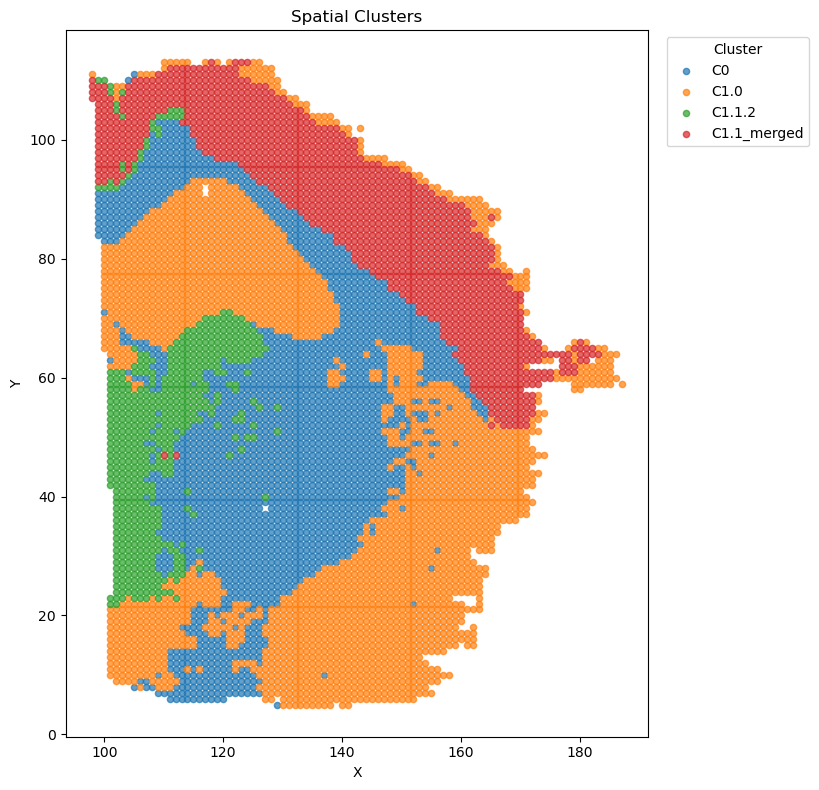

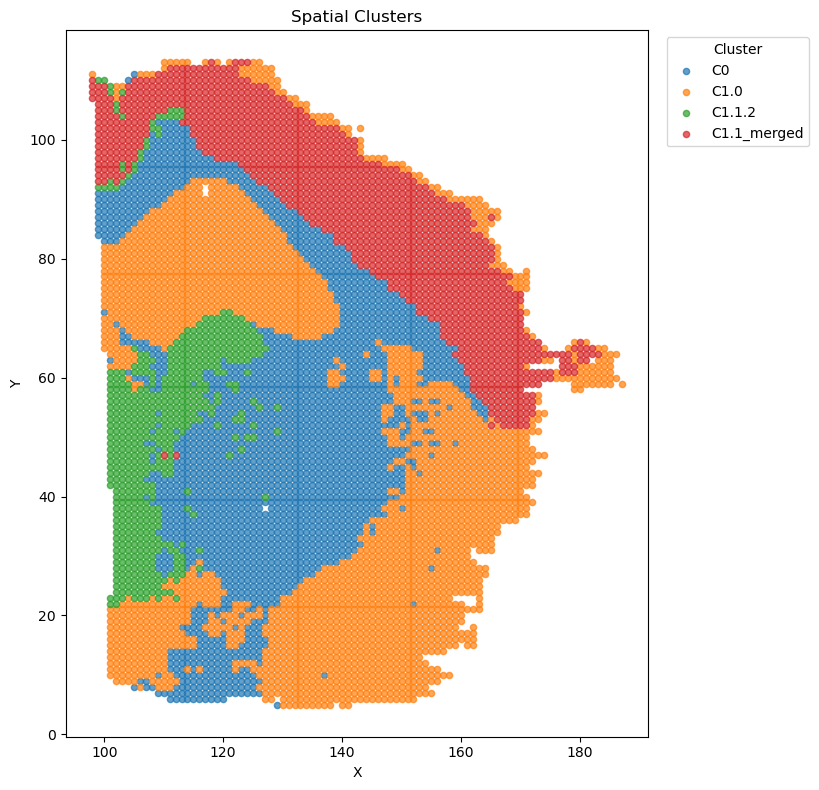

In [211]:
adata = merge_clusters(adata, ['C1.1.0', 'C1.1.1'], 'C1.1_merged')
plot_clusters(adata, save_path=None)

Subclustering 'C1.1.2' (589 cells)...


  Split into 7 subclusters
Plotting...


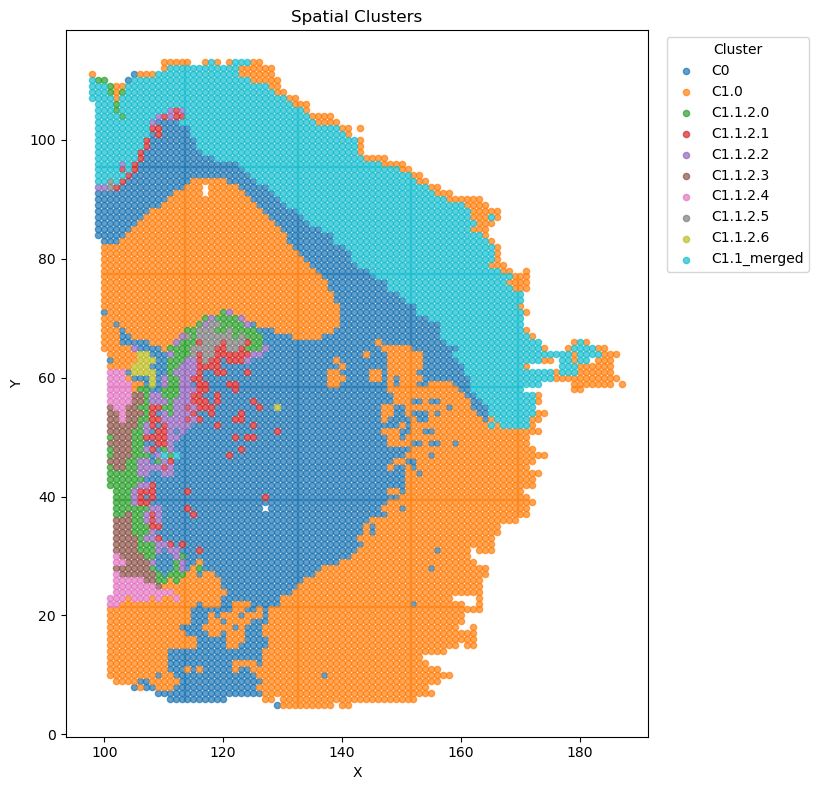

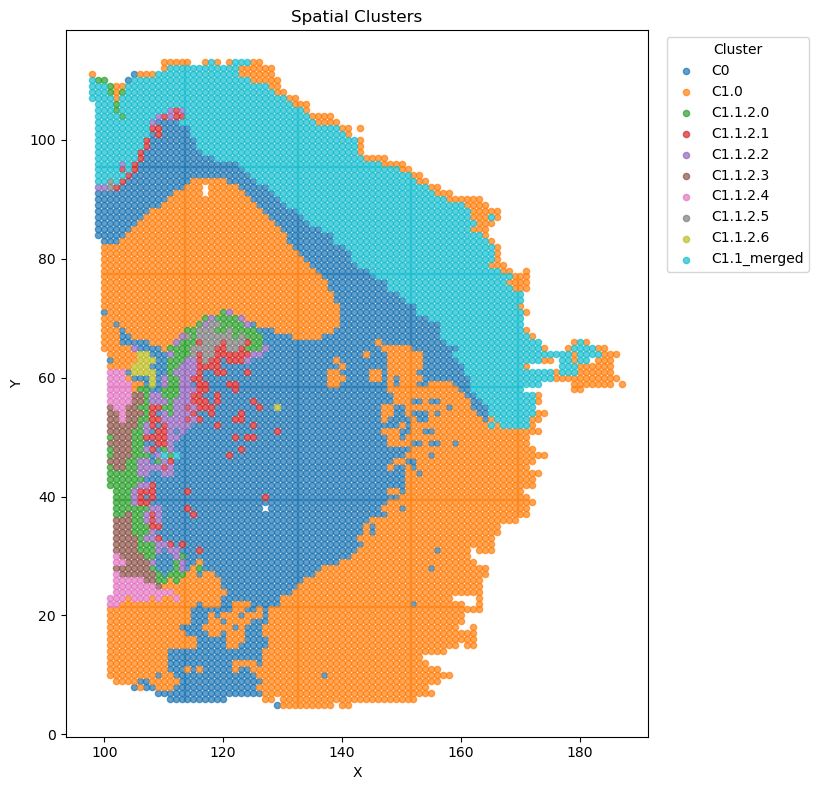

In [212]:
adata = subcluster(adata, 'C1.1.2', method='leiden', resolution=1)
plot_clusters(adata, save_path=None)